# Continuous Rectified Sidewalk Strip

Build labeled, vertically stacked sidewalk strips from ordered street sample points.

The first strip-building section rectifies each selected sidewalk tile independently, normalizes the tile canvas width, adds debug labels, and stacks the tiles so the continuity/order can be inspected by eye. The later LoFTR merge section optionally aligns adjacent clean rectified tiles at matched connection points and saves merged outputs.

## 1. Imports and Configuration

Edit `MANIFEST_CSV` and `POINT_IDS` first. The point order is used exactly as written.

In [11]:
import csv
import io
import os
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import cv2
import matplotlib.pyplot as plt
import numpy as np
from dotenv import load_dotenv
from google.cloud import storage
from PIL import Image
from sklearn.linear_model import LinearRegression, RANSACRegressor

# -----------------------------------------------------------------------------
# User configuration
# -----------------------------------------------------------------------------
MANIFEST_CSV = 'https://storage.cloud.google.com/cv-urban-accessibility-bucket/streetview/polygon_4v/20260404T133859Z/manifest.csv'
POINT_IDS = [f"{i:04d}" for i in range(286, 257, -1)]  # 286-258 inclusive, in reverse order to match walking direction
SIDES_TO_RENDER = ['left', 'right']

# 240 is fast but visibly pixelated. Use 480-720 for sharper inspection strips.
TARGET_SIDEWALK_WIDTH_PX = 480
RECTIFY_INTERPOLATION = cv2.INTER_CUBIC
DISPLAY_INTERPOLATION = 'lanczos'
DISPLAY_DPI = 160
DEPTH_RATIO = 1.6
MASKS_ROOT = 'v3/segmentation-results'
HFOV_DEG = 90
LABEL_BAR_HEIGHT = 54
WARNING_TILE_HEIGHT = 180

# Save full-resolution outputs locally; notebook display shows a full-strip preview.
SAVE_STRIPS = True
OUTPUT_DIR = 'continuous-sidewalk-strip-output'

# -----------------------------------------------------------------------------
# Environment / GCS
# -----------------------------------------------------------------------------
load_dotenv(Path('../.env'))
load_dotenv(Path('../../.env'))
GCS_BUCKET_NAME = os.environ.get('GCS_BUCKET_NAME', '')
GCP_PROJECT_ID = os.environ.get('GCP_PROJECT_ID', '')

print('Bucket:', GCS_BUCKET_NAME or '(missing)')
print('Project:', GCP_PROJECT_ID or '(missing)')
print('Manifest:', MANIFEST_CSV)
print('Point IDs:', POINT_IDS)

Bucket: cv-urban-accessibility-bucket
Project: cv-urban-accessibility
Manifest: https://storage.cloud.google.com/cv-urban-accessibility-bucket/streetview/polygon_4v/20260404T133859Z/manifest.csv
Point IDs: ['0286', '0285', '0284', '0283', '0282', '0281', '0280', '0279', '0278', '0277', '0276', '0275', '0274', '0273', '0272', '0271', '0270', '0269', '0268', '0267', '0266', '0265', '0264', '0263', '0262', '0261', '0260', '0259', '0258']


## 2. Manifest and GCS Helpers

The parser supports both naming styles used in this repo:

- `streetId-pointId_direction_lat_lon_heading.jpg`
- `pointId_direction_lat_lon_heading.jpg`

`MANIFEST_CSV` may be a local file path, `gs://bucket/blob.csv`, a GCS HTTPS URL, or a bucket-relative blob path.


In [12]:
from urllib.parse import unquote, urlparse

_FILENAME_RE_NEW = re.compile(
    r'^(\d+)-(\d+)_(forward|backward|left|right)_([-\d.]+)_([-\d.]+)_([\d.]+)\.\w+$'
)
_FILENAME_RE_OLD = re.compile(
    r'^(\d+)_(forward|backward|left|right)_([-\d.]+)_([-\d.]+)_([\d.]+)\.\w+$'
)


def normalize_point_id(point_id: str | int) -> str:
    s = str(point_id).strip()
    return s.zfill(4) if s.isdigit() else s


def parse_gcs_path(uri_or_blob: str | Path) -> tuple[str | None, str]:
    """Return (bucket, blob). bucket=None means this is not an explicit GCS URI."""
    s = str(uri_or_blob).strip()
    if s.startswith('gs://'):
        parts = s.split('/', 3)
        bucket = parts[2] if len(parts) > 2 else ''
        blob = parts[3] if len(parts) > 3 else ''
        return bucket, blob

    if s.startswith(('http://', 'https://')):
        parsed = urlparse(s)
        host = parsed.netloc
        path = unquote(parsed.path.lstrip('/'))

        # https://storage.cloud.google.com/<bucket>/<blob>
        # https://storage.googleapis.com/<bucket>/<blob>
        if host in {'storage.cloud.google.com', 'storage.googleapis.com'}:
            bucket, _, blob = path.partition('/')
            return bucket, blob

        # https://<bucket>.storage.googleapis.com/<blob>
        suffix = '.storage.googleapis.com'
        if host.endswith(suffix):
            bucket = host[:-len(suffix)]
            return bucket, path

    return None, s.lstrip('/')


def blob_from_gcs_uri(uri_or_blob: str) -> str:
    _, blob = parse_gcs_path(uri_or_blob)
    return blob


def download_gcs_bytes(bucket_name: str, blob_name: str) -> bytes:
    return storage.Client(project=GCP_PROJECT_ID).bucket(bucket_name).blob(blob_name).download_as_bytes()


def parse_image_filename(filename: str) -> dict[str, str] | None:
    name = Path(filename).name
    m_new = _FILENAME_RE_NEW.match(name)
    if m_new:
        street_id, point_id, direction, lat, lon, heading = m_new.groups()
        return {
            'street_id': street_id,
            'point_id': point_id,
            'index': point_id,
            'direction': direction,
            'lat': lat,
            'lon': lon,
            'heading': heading,
            'coordinate_folder': f'{point_id}_{lat}_{lon}',
        }

    m_old = _FILENAME_RE_OLD.match(name)
    if not m_old:
        return None
    point_id, direction, lat, lon, heading = m_old.groups()
    return {
        'street_id': '',
        'point_id': point_id,
        'index': point_id,
        'direction': direction,
        'lat': lat,
        'lon': lon,
        'heading': heading,
        'coordinate_folder': f'{point_id}_{lat}_{lon}',
    }



# Fallback for notebooks run out of order or kernels that still have an older config cell.
if 'resolve_local_path' not in globals():
    def find_project_root() -> Path:
        for start in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
            for candidate in [start, *start.parents]:
                if (candidate / '.env').exists() and (candidate / 's0-trials').exists():
                    return candidate
        return Path.cwd()

    PROJECT_ROOT = find_project_root()
    NOTEBOOK_DIR = PROJECT_ROOT / 's0-trials' / 'sidewalk-measurement-trials'

    def resolve_local_path(path: str | Path) -> Path:
        p = Path(path).expanduser()
        candidates = [p, PROJECT_ROOT / p, NOTEBOOK_DIR / p]
        for candidate in candidates:
            if candidate.exists():
                return candidate.resolve()
        return (PROJECT_ROOT / p).resolve()

def open_manifest_text(path: str | Path):
    """Open a manifest from a local path, gs:// URI, HTTPS GCS URL, or bucket blob path."""
    bucket_name, blob_name = parse_gcs_path(path)

    if bucket_name:
        data = download_gcs_bytes(bucket_name, blob_name)
        print(f'Manifest source: gs://{bucket_name}/{blob_name}')
        return io.StringIO(data.decode('utf-8-sig'))

    local_path = resolve_local_path(path)
    if local_path.exists():
        print(f'Manifest source: {local_path}')
        return local_path.open(newline='')

    # Convenience: allow bucket-relative CSV blobs, e.g.
    # MANIFEST_CSV = 'streetview/polygon_4v/20260404T133859Z/manifest.csv'
    if GCS_BUCKET_NAME:
        data = download_gcs_bytes(GCS_BUCKET_NAME, blob_name)
        print(f'Manifest source: gs://{GCS_BUCKET_NAME}/{blob_name}')
        return io.StringIO(data.decode('utf-8-sig'))

    raise FileNotFoundError(f'Manifest not found locally and GCS_BUCKET_NAME is not set: {path}')


def load_manifest(path: str | Path) -> dict[str, dict[str, dict[str, Any]]]:
    rows_by_point: dict[str, dict[str, dict[str, Any]]] = {}
    with open_manifest_text(path) as f:
        reader = csv.DictReader(f)
        for row in reader:
            if row.get('status') and row['status'] != 'uploaded':
                continue
            point_id = normalize_point_id(row.get('point_id', ''))
            direction = row.get('direction', '').strip()
            gcs_uri = row.get('gcs_uri', '').strip()
            if not point_id or direction not in {'forward', 'backward', 'left', 'right'} or not gcs_uri:
                continue
            blob = blob_from_gcs_uri(gcs_uri)
            parsed = parse_image_filename(blob) or {
                'point_id': point_id,
                'direction': direction,
                'lat': row.get('latitude', ''),
                'lon': row.get('longitude', ''),
                'heading': row.get('heading', ''),
                'coordinate_folder': f"{point_id}_{row.get('latitude', '')}_{row.get('longitude', '')}",
            }
            row = dict(row)
            row['blob_name'] = blob
            row['parsed'] = parsed
            rows_by_point.setdefault(point_id, {})[direction] = row
    return rows_by_point


class GCSClient:
    def __init__(self, project_id: str, bucket_name: str):
        self._client = storage.Client(project=project_id)
        self._bucket = self._client.bucket(bucket_name)
        self.bucket_name = bucket_name

    def download_as_bytes(self, blob_name: str) -> bytes:
        return self._bucket.blob(blob_name).download_as_bytes()

    def list_blobs(self, prefix: str) -> list[str]:
        return [b.name for b in self._bucket.list_blobs(prefix=prefix)]


def bytes_to_image(data: bytes) -> np.ndarray:
    return np.array(Image.open(io.BytesIO(data)).convert('RGB'))


def bytes_to_mask(data: bytes) -> np.ndarray:
    mask = np.array(Image.open(io.BytesIO(data)).convert('L'))
    return (mask > 127).astype(bool)


def resolve_masks_prefix(gcs: GCSClient, masks_root: str, parsed: dict[str, str]) -> tuple[str, str]:
    direction = parsed['direction']
    point_id = parsed['point_id']
    preferred_coord = parsed['coordinate_folder']
    preferred = f'{masks_root.rstrip("/")}/{preferred_coord}/{direction}'

    exact = [b for b in gcs.list_blobs(preferred + '/') if b.endswith('.png')]
    if exact:
        return preferred, preferred_coord

    all_for_point = gcs.list_blobs(f'{masks_root.rstrip("/")}/{point_id}_')
    coord_candidates: set[str] = set()
    marker = f'/{direction}/'
    for blob in all_for_point:
        if marker not in blob or not blob.endswith('.png'):
            continue
        rel = blob[len(masks_root.rstrip('/') + '/'):]
        coord_candidates.add(rel.split('/', 1)[0])

    if not coord_candidates:
        return preferred, preferred_coord

    if preferred_coord in coord_candidates:
        return preferred, preferred_coord

    def coord_distance_sq(coord_folder: str) -> float:
        m = re.match(r'^\d+_([-\d.]+)_([-\d.]+)$', coord_folder)
        if not m:
            return float('inf')
        try:
            d_lat = float(m.group(1)) - float(parsed['lat'])
            d_lon = float(m.group(2)) - float(parsed['lon'])
        except (TypeError, ValueError):
            return float('inf')
        return d_lat * d_lat + d_lon * d_lon

    chosen = sorted(coord_candidates, key=lambda c: (coord_distance_sq(c), c))[0]
    return f'{masks_root.rstrip("/")}/{chosen}/{direction}', chosen


def load_individual_sidewalk_masks(gcs: GCSClient, masks_prefix: str, shape: tuple[int, int]) -> list[dict[str, Any]]:
    blobs = [b for b in gcs.list_blobs(masks_prefix + '/sidewalk/') if b.endswith('.png')]
    masks = []
    H, W = shape
    for blob in blobs:
        mask = bytes_to_mask(gcs.download_as_bytes(blob))
        if mask.shape != shape:
            mask = cv2.resize(mask.astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST).astype(bool)
        cols = np.where(mask.any(axis=0))[0]
        if len(cols) == 0:
            continue
        side = 'left' if float(np.mean(cols)) < W / 2 else 'right'
        masks.append({
            'mask': mask,
            'side': side,
            'blob_name': blob,
            'area': int(mask.sum()),
        })
    masks.sort(key=lambda m: m['area'], reverse=True)
    return masks


manifest = load_manifest(MANIFEST_CSV)
gcs = GCSClient(GCP_PROJECT_ID, GCS_BUCKET_NAME)

for point_id in POINT_IDS:
    dirs = sorted(manifest.get(normalize_point_id(point_id), {}).keys())
    print(f'{normalize_point_id(point_id)}: {dirs}')

/Users/talha/Library/CloudStorage/Dropbox/s8/cmpe492/cv-urban-accessibility-senior-project/.venv/lib/python3.13/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Manifest source: gs://cv-urban-accessibility-bucket/streetview/polygon_4v/20260404T133859Z/manifest.csv


/Users/talha/Library/CloudStorage/Dropbox/s8/cmpe492/cv-urban-accessibility-senior-project/.venv/lib/python3.13/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


0286: ['backward', 'forward', 'left', 'right']
0285: ['backward', 'forward', 'left', 'right']
0284: ['backward', 'forward', 'left', 'right']
0283: ['backward', 'forward', 'left', 'right']
0282: ['backward', 'forward', 'left', 'right']
0281: ['backward', 'forward', 'left', 'right']
0280: ['backward', 'forward', 'left', 'right']
0279: ['backward', 'forward', 'left', 'right']
0278: ['backward', 'forward', 'left', 'right']
0277: ['backward', 'forward', 'left', 'right']
0276: ['backward', 'forward', 'left', 'right']
0275: ['backward', 'forward', 'left', 'right']
0274: ['backward', 'forward', 'left', 'right']
0273: ['backward', 'forward', 'left', 'right']
0272: ['backward', 'forward', 'left', 'right']
0271: ['backward', 'forward', 'left', 'right']
0270: ['backward', 'forward', 'left', 'right']
0269: ['backward', 'forward', 'left', 'right']
0268: ['backward', 'forward', 'left', 'right']
0267: ['backward', 'forward', 'left', 'right']
0266: ['backward', 'forward', 'left', 'right']
0265: ['backw

## 3. Rectification Utilities

These are adapted from `loftr_left_forward_matching.ipynb`, with a mirrored side-view fan rectifier for right-looking images.

In [13]:
BORDER_MARGIN = 3
RANSAC_RESIDUAL_THRESHOLD = 1.0
RANSAC_MIN_SAMPLES = 0.3
SHIFT_PERCENTILE = 10
ROAD_TOUCH_MARGIN = 20
ROAD_CONFIRMED_WEIGHT = 5.0


def find_row_edges(mask: np.ndarray, road_mask: np.ndarray | None = None,
                   border_margin: int = BORDER_MARGIN,
                   ransac_threshold: float = RANSAC_RESIDUAL_THRESHOLD,
                   ransac_min_samples: float = RANSAC_MIN_SAMPLES,
                   road_touch_margin: int = ROAD_TOUCH_MARGIN):
    sw_cols = np.where(mask.any(axis=0))[0]
    if len(sw_cols) == 0:
        H = mask.shape[0]
        return np.full(H, np.nan), np.full(H, np.nan), np.zeros(H, dtype=bool), np.zeros(H, dtype=bool), None

    sw_center = np.mean(sw_cols)
    if road_mask is not None and np.any(road_mask):
        road_center = np.mean(np.where(road_mask.any(axis=0))[0])
        is_left_sidewalk = sw_center < road_center
    else:
        is_left_sidewalk = None

    H, W = mask.shape
    left_edges = np.full(H, np.nan)
    right_edges = np.full(H, np.nan)
    valid = np.zeros(H, dtype=bool)
    extrapolated = np.zeros(H, dtype=bool)

    left_valid = np.zeros(H, dtype=bool)
    right_valid = np.zeros(H, dtype=bool)
    left_clipped = np.zeros(H, dtype=bool)
    right_clipped = np.zeros(H, dtype=bool)
    has_sidewalk = np.zeros(H, dtype=bool)
    road_confirmed_L = np.zeros(H, dtype=bool)
    road_confirmed_R = np.zeros(H, dtype=bool)

    for r in range(H):
        cols = np.where(mask[r])[0]
        if len(cols) == 0:
            continue
        has_sidewalk[r] = True
        left_col, right_col = cols[0], cols[-1]
        left_edges[r] = left_col
        right_edges[r] = right_col

        left_at_border = left_col < border_margin
        right_at_border = right_col >= W - border_margin
        left_valid[r] = not left_at_border
        right_valid[r] = not right_at_border
        left_clipped[r] = left_at_border
        right_clipped[r] = right_at_border

        if road_mask is not None and is_left_sidewalk is not None:
            road_cols = np.where(road_mask[r])[0]
            if len(road_cols) > 0:
                if is_left_sidewalk:
                    dist_right = np.min(np.abs(road_cols - right_col))
                    if dist_right <= road_touch_margin:
                        road_confirmed_R[r] = True
                        right_valid[r] = True
                        right_clipped[r] = False
                    else:
                        right_valid[r] = False
                else:
                    dist_left = np.min(np.abs(road_cols - left_col))
                    if dist_left <= road_touch_margin:
                        road_confirmed_L[r] = True
                        left_valid[r] = True
                        left_clipped[r] = False
                    else:
                        left_valid[r] = False

    both_valid = left_valid & right_valid
    left_valid_idx = np.where(left_valid)[0]
    right_valid_idx = np.where(right_valid)[0]
    edge_model = None

    if len(left_valid_idx) >= 2 and len(right_valid_idx) >= 2:
        a_L, b_L, inlier_mask_L = _fit_edge(left_valid_idx, left_edges, road_confirmed_L, side='left',
                                            ransac_threshold=ransac_threshold,
                                            ransac_min_samples=ransac_min_samples)
        a_R, b_R, inlier_mask_R = _fit_edge(right_valid_idx, right_edges, road_confirmed_R, side='right',
                                            ransac_threshold=ransac_threshold,
                                            ransac_min_samples=ransac_min_samples)
        edge_model = {
            'a_L': a_L, 'b_L': b_L,
            'a_R': a_R, 'b_R': b_R,
            'inlier_mask_L': inlier_mask_L,
            'inlier_mask_R': inlier_mask_R,
            'left_valid_idx': left_valid_idx,
            'right_valid_idx': right_valid_idx,
            'valid_idx': np.where(both_valid)[0],
            'road_confirmed_L': road_confirmed_L,
            'road_confirmed_R': road_confirmed_R,
        }
        for r in np.where(has_sidewalk)[0]:
            if left_clipped[r]:
                left_edges[r] = a_L * r + b_L
            if right_clipped[r]:
                right_edges[r] = a_R * r + b_R
            if left_clipped[r] or right_clipped[r]:
                extrapolated[r] = True
        valid = has_sidewalk.copy()
    else:
        valid = both_valid.copy()

    return left_edges, right_edges, valid, extrapolated, edge_model


def _fit_edge(valid_idx, edges, road_confirmed, side='left',
              ransac_threshold=RANSAC_RESIDUAL_THRESHOLD,
              ransac_min_samples=RANSAC_MIN_SAMPLES):
    rc_mask = road_confirmed[valid_idx]
    n_rc = rc_mask.sum()
    rc_rows = valid_idx[rc_mask]
    is_left = side == 'left'

    if n_rc >= 4:
        a, b = np.polyfit(rc_rows.astype(float), edges[rc_rows], 1)
        fitted_rc = a * rc_rows.astype(float) + b
        residuals_rc = edges[rc_rows] - fitted_rc
        b += np.percentile(residuals_rc, SHIFT_PERCENTILE if is_left else 100 - SHIFT_PERCENTILE)
        fitted_all = a * valid_idx.astype(float) + b
        residuals_all = edges[valid_idx] - fitted_all
        inlier_mask = (residuals_all < ransac_threshold) if is_left else (residuals_all > -ransac_threshold)
        inlier_mask[rc_mask] = True
        if inlier_mask.sum() >= 2:
            clean_idx = valid_idx[inlier_mask]
            weights = np.ones(len(clean_idx), dtype=float)
            weights[[road_confirmed[r] for r in clean_idx]] = ROAD_CONFIRMED_WEIGHT
            a, b = np.polyfit(clean_idx.astype(float), edges[clean_idx], 1, w=weights)
        return a, b, inlier_mask

    if len(valid_idx) >= 4:
        X = valid_idx.reshape(-1, 1).astype(float)
        sample_weights = np.ones(len(valid_idx), dtype=float)
        if n_rc > 0:
            sample_weights[rc_mask] = ROAD_CONFIRMED_WEIGHT
        ransac = RANSACRegressor(estimator=LinearRegression(), residual_threshold=ransac_threshold,
                                 min_samples=ransac_min_samples, random_state=42)
        ransac.fit(X, edges[valid_idx], sample_weight=sample_weights)
        a = ransac.estimator_.coef_[0]
        b = ransac.estimator_.intercept_
        fitted = a * valid_idx.astype(float) + b
        residuals = edges[valid_idx] - fitted
        inlier_mask = (residuals < ransac_threshold) if is_left else (residuals > -ransac_threshold)
        if n_rc > 0:
            inlier_mask[rc_mask] = True
        if inlier_mask.sum() >= 2:
            clean_idx = valid_idx[inlier_mask]
            weights = np.ones(len(clean_idx), dtype=float)
            weights[[road_confirmed[r] for r in clean_idx]] = ROAD_CONFIRMED_WEIGHT
            a, b = np.polyfit(clean_idx.astype(float), edges[clean_idx], 1, w=weights)
            fitted2 = a * clean_idx.astype(float) + b
            residuals_clean = edges[clean_idx] - fitted2
            b += np.percentile(residuals_clean, SHIFT_PERCENTILE if is_left else 100 - SHIFT_PERCENTILE)
            fitted3 = a * valid_idx.astype(float) + b
            residuals3 = edges[valid_idx] - fitted3
            inlier_mask = (residuals3 < ransac_threshold) if is_left else (residuals3 > -ransac_threshold)
            if n_rc > 0:
                inlier_mask[rc_mask] = True
    else:
        a, b = np.polyfit(valid_idx.astype(float), edges[valid_idx], 1)
        inlier_mask = np.ones(len(valid_idx), dtype=bool)
    return a, b, inlier_mask


def _compute_rectify_params(img: np.ndarray, model: dict[str, Any] | None, original_width: int | None = None):
    if original_width is None:
        original_width = img.shape[1]
    f_px = original_width / (2.0 * np.tan(np.radians(HFOV_DEG / 2.0)))
    if model is not None:
        denom = model['a_L'] - model['a_R']
        vp_y = (model['b_R'] - model['b_L']) / denom if abs(denom) > 1e-6 else 0
        vp_x = model['a_L'] * vp_y + model['b_L']
        cos_corr = np.cos(max(0.0, np.arctan((vp_x - img.shape[1] / 2.0) / f_px)))
    else:
        cos_corr = 1.0
    return f_px, cos_corr


def rectify_sidewalk(image_or_mask, left_edges, right_edges, valid_rows,
                     edge_model=None, target_width=None, is_mask=False,
                     cos_correction=1.0, f_px=None):
    H, W = image_or_mask.shape[:2]
    valid_widths = right_edges[valid_rows] - left_edges[valid_rows]
    if len(valid_widths) == 0:
        return image_or_mask, target_width or 100, 0
    if target_width is None:
        target_width = int(np.median(valid_widths) * cos_correction)

    valid_idx = np.where(valid_rows)[0]
    all_rows = np.arange(H)
    if len(valid_idx) < 2:
        left_interp = np.full(H, left_edges[valid_idx[0]] if len(valid_idx) else 0)
        right_interp = np.full(H, right_edges[valid_idx[0]] if len(valid_idx) else W - 1)
        vy = -1e8
        first_valid = 0
        last_valid = H - 1
        a_L, b_L = 0.0, left_interp[0]
        a_R, b_R = 0.0, right_interp[0]
    else:
        if edge_model is not None:
            a_L, b_L = edge_model['a_L'], edge_model['b_L']
            a_R, b_R = edge_model['a_R'], edge_model['b_R']
        else:
            valid_r = valid_idx.astype(float)
            a_L, b_L = np.polyfit(valid_r, left_edges[valid_idx], 1)
            a_R, b_R = np.polyfit(valid_r, right_edges[valid_idx], 1)
        left_interp = a_L * all_rows + b_L
        right_interp = a_R * all_rows + b_R
        vy = (b_R - b_L) / (a_L - a_R) if abs(a_L - a_R) > 1e-6 else -1e8
        first_valid = valid_idx[0]
        last_valid = valid_idx[-1]

    use_perp = False
    vp_perp_x = 0.0
    cy = H / 2.0
    if f_px is not None and abs(a_L - a_R) > 1e-6:
        vp_x = a_L * vy + b_L
        vp_x_offset = vp_x - W / 2.0
        if abs(vp_x_offset) > 1e-6:
            a_avg = (a_L + a_R) / 2.0
            sign = 1.0 if a_avg > 0 else -1.0
            vp_perp_x = W / 2.0 + sign * f_px * f_px / abs(vp_x_offset)
            use_perp = True

    row_scale = np.ones(H, dtype=np.float64)
    ref_dist = abs(last_valid - vy)
    max_stretch = 50.0
    for r in range(first_valid, last_valid + 1):
        dist = abs(r - vy)
        row_scale[r] = min((ref_dist / dist) ** 2 if dist > 0 else max_stretch, max_stretch)

    cum_real = np.cumsum(row_scale)
    cum_real = cum_real - cum_real[0]
    out_height = int(np.ceil(cum_real[-1])) + 1
    out_rows = np.arange(out_height, dtype=np.float32)
    src_row_for_out = np.interp(out_rows, cum_real, np.arange(H, dtype=np.float32))

    # Padding is removed
    padding = 0
    out_width = target_width
    map_x = np.zeros((out_height, out_width), dtype=np.float32)
    map_y = np.zeros((out_height, out_width), dtype=np.float32)
    out_cols = np.arange(out_width, dtype=np.float32)

    for out_r in range(out_height):
        src_r = src_row_for_out[out_r]
        src_r_int = int(src_r)
        L = left_interp[min(src_r_int, H - 1)]
        R = right_interp[min(src_r_int, H - 1)]
        src_r_frac = src_r - src_r_int
        if src_r_frac > 0 and src_r_int + 1 < H:
            L = L * (1 - src_r_frac) + left_interp[src_r_int + 1] * src_r_frac
            R = R * (1 - src_r_frac) + right_interp[src_r_int + 1] * src_r_frac

        src_width = R - L
        if src_width <= 0:
            map_x[out_r, :] = -1
            map_y[out_r, :] = src_r
            continue

        cx = (L + R) / 2.0
        if use_perp and src_r > cy + 1:
            dx_perp = vp_perp_x - cx
            if abs(dx_perp) > 1e-6:
                perp_slope = (cy - src_r) / dx_perp
                denom_L = 1.0 - a_L * perp_slope
                denom_R = 1.0 - a_R * perp_slope
                if abs(denom_L) > 1e-9 and abs(denom_R) > 1e-9:
                    t_L = (L - cx) / denom_L
                    t_R = (R - cx) / denom_R
                    perp_span = t_R - t_L
                    if perp_span > 0:
                        t = t_L + (out_cols - padding) / target_width * perp_span
                        map_x[out_r, :] = cx + t
                        map_y[out_r, :] = src_r + t * perp_slope
                        continue

        scale = src_width / target_width
        map_x[out_r, :] = L + (out_cols - padding) * scale
        map_y[out_r, :] = src_r

    flags = cv2.INTER_NEAREST if is_mask else globals().get('RECTIFY_INTERPOLATION', cv2.INTER_CUBIC)
    inp = image_or_mask.astype(np.uint8) if is_mask else image_or_mask
    warped = cv2.remap(inp, map_x, map_y, interpolation=flags, borderMode=cv2.BORDER_CONSTANT)
    if is_mask:
        warped = warped.astype(bool)
    return warped, target_width, padding


def rectify_side_datadriven_fan(image, single_mask, direction: str, target_width=None, is_mask=False, depth_ratio=1.6):
    if direction not in {'left', 'right'}:
        raise ValueError(f'direction must be left or right, got {direction!r}')

    safe_image = image.astype(np.uint8) if image.dtype == bool else image
    rotate_code = cv2.ROTATE_90_COUNTERCLOCKWISE if direction == 'left' else cv2.ROTATE_90_CLOCKWISE
    img_rot = cv2.rotate(safe_image, rotate_code)
    mask_rot = cv2.rotate(single_mask.astype(np.uint8), rotate_code).astype(bool)
    H_rot, W_rot = img_rot.shape[:2]

    left_edges, right_edges, valid, extrap, edge_model = find_row_edges(mask_rot)
    valid_widths = right_edges[valid] - left_edges[valid]
    if len(valid_widths) == 0:
        return image, target_width or 100, 0
    if target_width is None:
        target_width = int(np.median(valid_widths))

    out_width = target_width
    out_height = H_rot
    padding = 0
    if edge_model is not None:
        a_L, b_L = edge_model['a_L'], edge_model['b_L']
        a_R, b_R = edge_model['a_R'], edge_model['b_R']
    else:
        valid_idx = np.where(valid)[0]
        a_L, b_L = np.polyfit(valid_idx, left_edges[valid_idx], 1)
        a_R, b_R = np.polyfit(valid_idx, right_edges[valid_idx], 1)

    out_x_grid, out_y_grid = np.meshgrid(np.arange(out_width), np.arange(out_height))
    x_norm = out_x_grid / max(out_width - 1, 1)
    stretch_factor = 1.0 + (depth_ratio - 1.0) * x_norm
    cy_rot = H_rot / 2.0
    src_y = cy_rot + (out_y_grid - cy_rot) * stretch_factor
    L = a_L * src_y + b_L
    R = a_R * src_y + b_R
    src_x = L + x_norm * (R - L)

    flags = cv2.INTER_NEAREST if is_mask else globals().get('RECTIFY_INTERPOLATION', cv2.INTER_CUBIC)
    inp = img_rot.astype(np.uint8) if is_mask else img_rot
    warped = cv2.remap(inp, src_x.astype(np.float32), src_y.astype(np.float32),
                       interpolation=flags, borderMode=cv2.BORDER_CONSTANT, borderValue=0)
    if is_mask:
        warped = warped.astype(bool)
    return warped, target_width, padding

## 4. Tile Building and Labeling

Each tile carries enough provenance to debug order, direction, mask choice, and rectification output shape.

In [14]:
@dataclass
class TileResult:
    image: np.ndarray
    status: str
    side_strip: str
    point_id: str
    direction: str
    selected_side: str
    method: str
    image_blob: str = ''
    mask_blob: str = ''
    message: str = ''
    shape: tuple[int, ...] | None = None
    clean_image: Any = None
    clean_mask: Any = None
    meta: dict[str, Any] | None = None


def select_mask(masks: list[dict[str, Any]], selected_side: str, direction: str) -> dict[str, Any] | None:
    if direction in {'left', 'right'} and selected_side == 'largest':
        return masks[0] if masks else None
    side_matches = [m for m in masks if m['side'] == selected_side]
    return side_matches[0] if side_matches else None


def rectify_tile(img: np.ndarray, mask: np.ndarray, direction: str, method: str,
                 target_width: int = TARGET_SIDEWALK_WIDTH_PX) -> tuple[np.ndarray, np.ndarray]:
    if method == 'side-view-fan':
        rect_img, w, pad = rectify_side_datadriven_fan(
            img, mask, direction=direction, target_width=target_width, depth_ratio=DEPTH_RATIO
        )
        rect_mask, _, _ = rectify_side_datadriven_fan(
            mask, mask, direction=direction, target_width=w, is_mask=True, depth_ratio=DEPTH_RATIO
        )
        return rect_img, rect_mask

    if method == 'geometry':
        left, right, valid, extrap, model = find_row_edges(mask)
        f_px, cos_corr = _compute_rectify_params(img, model)
        rect_img, w, pad = rectify_sidewalk(
            img, left, right, valid, edge_model=model, target_width=target_width,
            f_px=f_px, cos_correction=cos_corr
        )
        rect_mask, _, _ = rectify_sidewalk(
            mask, left, right, valid, edge_model=model, target_width=w, is_mask=True,
            f_px=f_px, cos_correction=cos_corr
        )
        return rect_img, rect_mask

    raise ValueError(f'Unknown rectification method: {method}')


def normalize_canvas_width(img: np.ndarray, canvas_width: int) -> np.ndarray:
    if img.ndim == 2:
        img = np.repeat(img[:, :, None], 3, axis=2)
    h, w = img.shape[:2]
    if w == canvas_width:
        return img
    if w > canvas_width:
        x0 = (w - canvas_width) // 2
        return img[:, x0:x0 + canvas_width]
    pad_left = (canvas_width - w) // 2
    pad_right = canvas_width - w - pad_left
    return np.pad(img, ((0, 0), (pad_left, pad_right), (0, 0)), mode='constant', constant_values=0)


def normalize_mask_width(mask: np.ndarray, canvas_width: int) -> np.ndarray:
    if mask.ndim == 3:
        mask = mask.any(axis=2)
    h, w = mask.shape[:2]
    if w == canvas_width:
        return mask.astype(bool)
    if w > canvas_width:
        x0 = (w - canvas_width) // 2
        return mask[:, x0:x0 + canvas_width].astype(bool)
    pad_left = (canvas_width - w) // 2
    pad_right = canvas_width - w - pad_left
    return np.pad(mask.astype(bool), ((0, 0), (pad_left, pad_right)), mode='constant', constant_values=False)


def image_id_from_blob(blob_name: str) -> str:
    stem = Path(blob_name).stem
    m = re.match(r'^(.+?)_(forward|backward|left|right)_', stem)
    return m.group(1) if m else stem


def add_image_badge(img: np.ndarray, image_id: str, direction: str, transform_note: str = '') -> np.ndarray:
    if img.ndim == 2:
        img = np.repeat(img[:, :, None], 3, axis=2)
    out = img.copy()
    h, w = out.shape[:2]
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = max(0.55, min(1.0, w / 720.0))
    thickness = max(1, int(round(font_scale * 2)))
    lines = [f'ID: {image_id}', f'DIR: {direction.upper()}']
    if transform_note:
        lines.append(transform_note.upper())
    sizes = [cv2.getTextSize(line, font, font_scale, thickness)[0] for line in lines]
    box_w = min(w - 16, max(size[0] for size in sizes) + 24)
    box_h = 26 * len(lines) + 18
    overlay = out.copy()
    cv2.rectangle(overlay, (8, 8), (8 + box_w, 8 + box_h), (15, 22, 30), -1)
    out = cv2.addWeighted(overlay, 0.72, out, 0.28, 0)
    y = 34
    for line in lines:
        cv2.putText(out, line, (20, y), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)
        y += 26
    return out


def add_label_bar(img: np.ndarray, label: str, status: str = 'ok') -> np.ndarray:
    if img.ndim == 2:
        img = np.repeat(img[:, :, None], 3, axis=2)
    h, w = img.shape[:2]
    bar = np.zeros((LABEL_BAR_HEIGHT, w, 3), dtype=np.uint8)
    bar[:] = (32, 42, 52) if status == 'ok' else (104, 43, 43)

    font = cv2.FONT_HERSHEY_SIMPLEX
    lines = [label]
    max_chars = max(30, int(w / 8.0))
    if len(label) > max_chars:
        lines = [label[:max_chars], label[max_chars:max_chars * 2]]
    y = 20
    for line in lines[:2]:
        cv2.putText(bar, line, (8, y), font, 0.48, (255, 255, 255), 1, cv2.LINE_AA)
        y += 22
    return np.vstack([bar, img])


def warning_tile(canvas_width: int, label: str) -> np.ndarray:
    tile = np.zeros((WARNING_TILE_HEIGHT, canvas_width, 3), dtype=np.uint8)
    tile[:] = (58, 45, 45)
    cv2.putText(tile, 'MISSING / SKIPPED', (12, 42), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 230, 230), 2, cv2.LINE_AA)
    cv2.putText(tile, label[:max(20, canvas_width // 8)], (12, 82), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (255, 255, 255), 1, cv2.LINE_AA)
    return tile


def build_tile(side_strip: str, point_id: str, direction: str, selected_side: str, method: str,
               canvas_width: int, cache: dict[tuple[str, str], dict[str, Any]]) -> TileResult:
    point_id = normalize_point_id(point_id)
    key = (point_id, direction)
    label_prefix = f'strip={side_strip} | point={point_id} | view={direction} | side={selected_side} | {method}'

    row = manifest.get(point_id, {}).get(direction)
    if row is None:
        msg = f'{label_prefix} | no manifest row'
        return TileResult(warning_tile(canvas_width, msg), 'missing', side_strip, point_id, direction, selected_side, method, message=msg)

    try:
        if key not in cache:
            blob = row['blob_name']
            parsed = row['parsed']
            img = bytes_to_image(gcs.download_as_bytes(blob))
            masks_prefix, coord = resolve_masks_prefix(gcs, MASKS_ROOT, parsed)
            masks = load_individual_sidewalk_masks(gcs, masks_prefix, img.shape[:2])
            cache[key] = {'row': row, 'image': img, 'masks': masks, 'masks_prefix': masks_prefix, 'coord': coord}
        item = cache[key]
        img = item['image']
        masks = item['masks']
        mask_item = select_mask(masks, selected_side, direction)
        if mask_item is None:
            msg = f'{label_prefix} | no mask found | prefix={item["masks_prefix"]}/sidewalk/'
            return TileResult(warning_tile(canvas_width, msg), 'missing', side_strip, point_id, direction, selected_side, method,
                              image_blob=row['blob_name'], message=msg)

        rect_img, rect_mask = rectify_tile(img, mask_item['mask'], direction, method)
        transform_note = ''
        if direction == 'backward':
            rect_img = cv2.flip(rect_img, -1)
            rect_mask = cv2.flip(rect_mask.astype(np.uint8), -1).astype(bool)
            transform_note = 'flip_xy'

        rect_img = normalize_canvas_width(rect_img, canvas_width)
        rect_mask = normalize_mask_width(rect_mask, canvas_width)
        clean_img = rect_img.copy()
        clean_mask = rect_mask.copy()
        shape = rect_img.shape
        image_id = image_id_from_blob(row['blob_name'])
        meta = {
            'side_strip': side_strip,
            'point_id': point_id,
            'direction': direction,
            'selected_side': selected_side,
            'method': method,
            'image_id': image_id,
            'image_blob': row['blob_name'],
            'mask_blob': mask_item['blob_name'],
            'transform': transform_note or 'none',
            'shape': shape,
        }
        rect_img = add_image_badge(rect_img, image_id, direction, transform_note=transform_note)
        label = (
            f'image_id={image_id} | direction={direction} | transform={transform_note or "none"} | {label_prefix} | img={Path(row["blob_name"]).name} | '
            f'mask={Path(mask_item["blob_name"]).name} | shape={shape[1]}x{shape[0]}'
        )
        labeled = add_label_bar(rect_img, label, status='ok')
        return TileResult(labeled, 'ok', side_strip, point_id, direction, selected_side, method,
                          image_blob=row['blob_name'], mask_blob=mask_item['blob_name'], shape=shape,
                          clean_image=clean_img, clean_mask=clean_mask, meta=meta)
    except Exception as exc:
        msg = f'{label_prefix} | ERROR: {type(exc).__name__}: {exc}'
        image_blob = row.get('blob_name', '') if row else ''
        return TileResult(warning_tile(canvas_width, msg), 'error', side_strip, point_id, direction, selected_side, method,
                          image_blob=image_blob, message=msg)

## 5. Strip Sequence

The stack is built in bottom-to-top order, then displayed with the top of the final image at the top of the figure. That means the first tile in the sequence appears at the bottom of the strip.

In [15]:
def strip_sequence(side_strip: str, point_ids: list[str]) -> list[tuple[str, str, str, str]]:
    point_ids = [normalize_point_id(p) for p in point_ids]
    seq: list[tuple[str, str, str, str]] = []
    if side_strip == 'left':
        side_view = ('left', 'largest', 'side-view-fan')
        forward = ('forward', 'left', 'geometry')
        backward_bridge_side = 'right'
    elif side_strip == 'right':
        side_view = ('right', 'largest', 'side-view-fan')
        forward = ('forward', 'right', 'geometry')
        backward_bridge_side = 'left'
    else:
        raise ValueError(f'Unknown side strip: {side_strip}')

    for idx, point_id in enumerate(point_ids):
        seq.append((point_id, *side_view))
        seq.append((point_id, *forward))
        if idx + 1 < len(point_ids):
            next_point = point_ids[idx + 1]
            seq.append((next_point, 'backward', backward_bridge_side, 'geometry'))
    return seq


for side in SIDES_TO_RENDER:
    print(f'\n{side.upper()} strip bottom-to-top sequence:')
    for item in strip_sequence(side, POINT_IDS):
        print('  ', item)


LEFT strip bottom-to-top sequence:
   ('0286', 'left', 'largest', 'side-view-fan')
   ('0286', 'forward', 'left', 'geometry')
   ('0285', 'backward', 'right', 'geometry')
   ('0285', 'left', 'largest', 'side-view-fan')
   ('0285', 'forward', 'left', 'geometry')
   ('0284', 'backward', 'right', 'geometry')
   ('0284', 'left', 'largest', 'side-view-fan')
   ('0284', 'forward', 'left', 'geometry')
   ('0283', 'backward', 'right', 'geometry')
   ('0283', 'left', 'largest', 'side-view-fan')
   ('0283', 'forward', 'left', 'geometry')
   ('0282', 'backward', 'right', 'geometry')
   ('0282', 'left', 'largest', 'side-view-fan')
   ('0282', 'forward', 'left', 'geometry')
   ('0281', 'backward', 'right', 'geometry')
   ('0281', 'left', 'largest', 'side-view-fan')
   ('0281', 'forward', 'left', 'geometry')
   ('0280', 'backward', 'right', 'geometry')
   ('0280', 'left', 'largest', 'side-view-fan')
   ('0280', 'forward', 'left', 'geometry')
   ('0279', 'backward', 'right', 'geometry')
   ('0279', 

## 6. Build and Display Strips

This cell performs the GCS downloads and rectifications. Re-run after editing the point list or rendering parameters.

In [16]:
CANVAS_WIDTH = TARGET_SIDEWALK_WIDTH_PX + 2 * int(TARGET_SIDEWALK_WIDTH_PX * 0.3)
cache: dict[tuple[str, str], dict[str, Any]] = {}
all_results: list[TileResult] = []
strips: dict[str, np.ndarray] = {}
strip_tile_results_bottom_to_top: dict[str, list[TileResult]] = {}

for side in SIDES_TO_RENDER:
    tiles: list[np.ndarray] = []
    tile_results: list[TileResult] = []
    print(f'\nBuilding {side} sidewalk strip...')
    for point_id, direction, selected_side, method in strip_sequence(side, POINT_IDS):
        result = build_tile(side, point_id, direction, selected_side, method, CANVAS_WIDTH, cache)
        all_results.append(result)
        tile_results.append(result)
        tiles.append(result.image)
        status_note = result.status.upper()
        extra = f' mask={Path(result.mask_blob).name}' if result.mask_blob else result.message
        print(f'  [{status_note}] point={point_id} view={direction} side={selected_side} method={method} {extra}')

    # Sequence is bottom-to-top. Reverse for normal image coordinates/display.
    max_w = max(t.shape[1] for t in tiles) if tiles else CANVAS_WIDTH
    normalized_tiles = [normalize_canvas_width(t, max_w) for t in tiles]
    strip_tile_results_bottom_to_top[side] = tile_results
    strips[side] = np.vstack(list(reversed(normalized_tiles))) if normalized_tiles else warning_tile(CANVAS_WIDTH, f'No tiles for {side}')

print('\nStatus table:')
print('status,strip,point,direction,side,method,image_blob,mask_blob,message')
for r in all_results:
    print(','.join([
        r.status,
        r.side_strip,
        r.point_id,
        r.direction,
        r.selected_side,
        r.method,
        Path(r.image_blob).name if r.image_blob else '',
        Path(r.mask_blob).name if r.mask_blob else '',
        str(r.message).replace(',', ';'),
    ]))


Building left sidewalk strip...
  [MISSING] point=0286 view=left side=largest method=side-view-fan strip=left | point=0286 | view=left | side=largest | side-view-fan | no mask found | prefix=v3/segmentation-results/0286_40.9716374_29.0680305/left/sidewalk/
  [MISSING] point=0286 view=forward side=left method=geometry strip=left | point=0286 | view=forward | side=left | geometry | no mask found | prefix=v3/segmentation-results/0286_40.9716374_29.0680305/forward/sidewalk/
  [MISSING] point=0285 view=backward side=right method=geometry strip=left | point=0285 | view=backward | side=right | geometry | no mask found | prefix=v3/segmentation-results/0285_40.9716797_29.067997/backward/sidewalk/
  [MISSING] point=0285 view=left side=largest method=side-view-fan strip=left | point=0285 | view=left | side=largest | side-view-fan | no mask found | prefix=v3/segmentation-results/0285_40.9716797_29.067997/left/sidewalk/
  [MISSING] point=0285 view=forward side=left method=geometry strip=left | poi

/Users/talha/Library/CloudStorage/Dropbox/s8/cmpe492/cv-urban-accessibility-senior-project/.venv/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


  [OK] point=0278 view=backward side=right method=geometry  mask=mask_000.png
  [OK] point=0278 view=left side=largest method=side-view-fan  mask=mask_000.png


/Users/talha/Library/CloudStorage/Dropbox/s8/cmpe492/cv-urban-accessibility-senior-project/.venv/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/talha/Library/CloudStorage/Dropbox/s8/cmpe492/cv-urban-accessibility-senior-project/.venv/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


  [OK] point=0278 view=forward side=left method=geometry  mask=mask_000.png
  [OK] point=0277 view=backward side=right method=geometry  mask=mask_000.png
  [OK] point=0277 view=left side=largest method=side-view-fan  mask=mask_002.png
  [OK] point=0277 view=forward side=left method=geometry  mask=mask_001.png
  [OK] point=0276 view=backward side=right method=geometry  mask=mask_000.png
  [OK] point=0276 view=left side=largest method=side-view-fan  mask=mask_000.png


...

  [OK] point=0265 view=right side=largest method=side-view-fan  mask=mask_000.png
  [MISSING] point=0265 view=forward side=right method=geometry strip=right | point=0265 | view=forward | side=right | geometry | no mask found | prefix=v3/segmentation-results/0265_40.9727625_29.0659514/forward/sidewalk/
  [OK] point=0264 view=backward side=left method=geometry  mask=mask_001.png
  [OK] point=0264 view=right side=largest method=side-view-fan  mask=mask_000.png
  [MISSING] point=0264 view=forward side=right method=geometry strip=right | point=0264 | view=forward | side=right | geometry | no mask found | prefix=v3/segmentation-results/0264_40.9728163_29.0658562/forward/sidewalk/
  [MISSING] point=0263 view=backward side=left method=geometry strip=right | point=0263 | view=backward | side=left | geometry | no mask found | prefix=v3/segmentation-results/0263_40.9728701_29.0657609/backward/sidewalk/
  [OK] point=0263 view=right side=largest method=side-view-fan  mask=mask_000.png
  [OK] point=

/Users/talha/Library/CloudStorage/Dropbox/s8/cmpe492/cv-urban-accessibility-senior-project/.venv/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/talha/Library/CloudStorage/Dropbox/s8/cmpe492/cv-urban-accessibility-senior-project/.venv/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/talha/Library/CloudStorage/Dropbox/s8/cmpe492/cv-urban-accessibility-senior-project/.venv/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


  [MISSING] point=0262 view=right side=largest method=side-view-fan strip=right | point=0262 | view=right | side=largest | side-view-fan | no mask found | prefix=v3/segmentation-results/0262_40.972922_29.0656642/right/sidewalk/
  [MISSING] point=0262 view=forward side=right method=geometry strip=right | point=0262 | view=forward | side=right | geometry | no mask found | prefix=v3/segmentation-results/0262_40.972922_29.0656642/forward/sidewalk/
  [MISSING] point=0261 view=backward side=left method=geometry strip=right | point=0261 | view=backward | side=left | geometry | no mask found | prefix=v3/segmentation-results/0261_40.9729664_29.0655616/backward/sidewalk/
  [OK] point=0261 view=right side=largest method=side-view-fan  mask=mask_001.png
  [OK] point=0261 view=forward side=right method=geometry  mask=mask_001.png
  [OK] point=0260 view=backward side=left method=geometry  mask=mask_001.png
  [OK] point=0260 view=right side=largest method=side-view-fan  mask=mask_000.png
  [OK] point

/Users/talha/Library/CloudStorage/Dropbox/s8/cmpe492/cv-urban-accessibility-senior-project/.venv/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


  [MISSING] point=0259 view=right side=largest method=side-view-fan strip=right | point=0259 | view=right | side=largest | side-view-fan | no mask found | prefix=v3/segmentation-results/0259_40.9730695_29.0653668/right/sidewalk/
  [MISSING] point=0259 view=forward side=right method=geometry strip=right | point=0259 | view=forward | side=right | geometry | no mask found | prefix=v3/segmentation-results/0259_40.9730695_29.0653668/forward/sidewalk/
  [OK] point=0258 view=backward side=left method=geometry  mask=mask_001.png
  [OK] point=0258 view=right side=largest method=side-view-fan  mask=mask_000.png
  [MISSING] point=0258 view=forward side=right method=geometry strip=right | point=0258 | view=forward | side=right | geometry | no mask found | prefix=v3/segmentation-results/0258_40.9730953_29.0653181/forward/sidewalk/

Status table:
status,strip,point,direction,side,method,image_blob,mask_blob,message
missing,left,0286,left,largest,side-view-fan,012-0286_left_40.9716374_29.0680305_304.

## 7. Visualization

Labels are embedded in each tile. The top of each displayed image is the top of the final strip; the sequence printed above tells you the bottom-to-top construction order.

Saved full strip: continuous-sidewalk-strip-output/left_sidewalk_strip_FULL.png  (768x170830 px)
Saved full strip: continuous-sidewalk-strip-output/right_sidewalk_strip_FULL.png  (768x46323 px)

LEFT full strip size: 768x170830 px


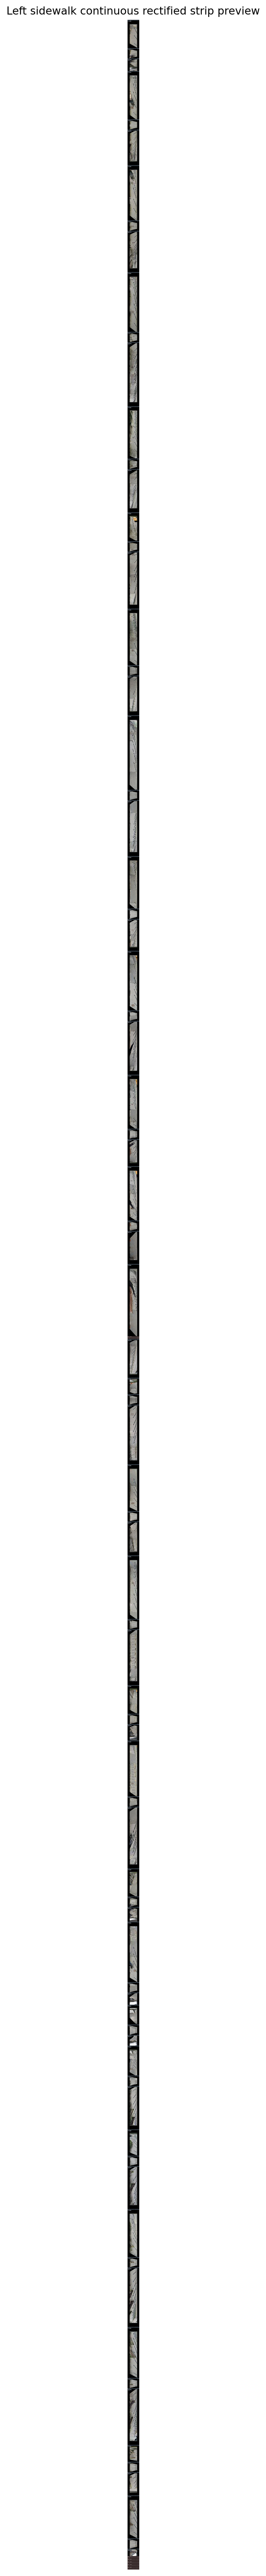


RIGHT full strip size: 768x46323 px


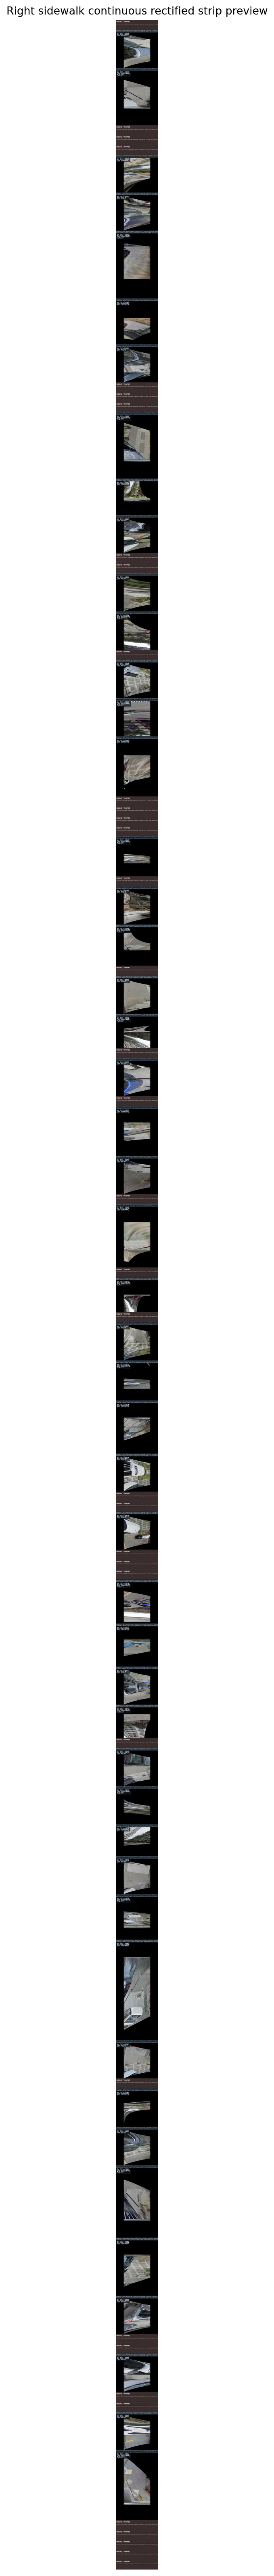

In [17]:
def save_strip_outputs():
    if not SAVE_STRIPS:
        return
    out_dir = Path(OUTPUT_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)
    for side, strip in strips.items():
        out_path = out_dir / f'{side}_sidewalk_strip_FULL.png'
        Image.fromarray(strip).save(out_path)
        print(f'Saved full strip: {out_path}  ({strip.shape[1]}x{strip.shape[0]} px)')


def display_full_strip_preview():
    for side, strip in strips.items():
        print(f'\n{side.upper()} full strip size: {strip.shape[1]}x{strip.shape[0]} px')
        fig_w = max(8, strip.shape[1] / 90)
        fig_h = max(8, min(40, strip.shape[0] / 120))
        fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=globals().get('DISPLAY_DPI', 160))
        ax.imshow(strip, interpolation=globals().get('DISPLAY_INTERPOLATION', 'lanczos'))
        ax.set_title(f'{side.capitalize()} sidewalk continuous rectified strip preview')
        ax.axis('off')
        plt.tight_layout()
        plt.show()


save_strip_outputs()
display_full_strip_preview()

## 8. LoFTR-Merged Strip

This section aligns adjacent clean rectified tiles using LoFTR connection points and saves separate merged outputs. It does not replace the debug stacked strip above.

In [18]:
import torch
import kornia.feature as KF

LOFTR_WEIGHTS = 'outdoor'
LOFTR_LONG_SIDE = 840
MIN_CONFIDENCE = 0.5
RESTRICT_TO_SIDEWALK = True
ROAD_VIEW_MATCH_KEEP_RATIO = 0.45
ROAD_VIEW_MATCH_KEEP_PERCENT = int(round(ROAD_VIEW_MATCH_KEEP_RATIO * 100))
MIN_RANSAC_INLIERS = 4
FALLBACK_GAP_PX = 0

loftr_device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
print('LoFTR device:', loftr_device)
print('Loading LoFTR weights:', LOFTR_WEIGHTS)
matcher = KF.LoFTR(pretrained=LOFTR_WEIGHTS).eval().to(loftr_device)

LoFTR device: mps
Loading LoFTR weights: outdoor


In [19]:
def to_loftr_tensor(img_rgb: np.ndarray, long_side: int):
    h, w = img_rgb.shape[:2]
    s = long_side / max(h, w)
    new_w, new_h = int(round(w * s)), int(round(h * s))
    new_w -= new_w % 8
    new_h -= new_h % 8
    new_w = max(8, new_w)
    new_h = max(8, new_h)
    resized = cv2.resize(img_rgb, (new_w, new_h), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
    tensor = torch.from_numpy(gray).float()[None, None] / 255.0
    return tensor, w / new_w, h / new_h


def points_in_mask(points: np.ndarray, mask: np.ndarray) -> np.ndarray:
    if len(points) == 0:
        return np.zeros(0, dtype=bool)
    xs = np.clip(points[:, 0].round().astype(int), 0, mask.shape[1] - 1)
    ys = np.clip(points[:, 1].round().astype(int), 0, mask.shape[0] - 1)
    return mask[ys, xs]


def tile_label(tile: TileResult) -> str:
    meta = tile.meta or {}
    return f"{meta.get('point_id', tile.point_id)} {meta.get('direction', tile.direction)} {meta.get('selected_side', tile.selected_side)}"


def road_view_crop_bounds(tile: TileResult) -> tuple[int, int, str]:
    h = int(tile.clean_image.shape[0])
    if tile.direction == 'forward':
        y0 = int(h * (1.0 - ROAD_VIEW_MATCH_KEEP_RATIO))
        return y0, h, f'forward-bottom{ROAD_VIEW_MATCH_KEEP_PERCENT}'
    if tile.direction == 'backward':
        y1 = int(h * ROAD_VIEW_MATCH_KEEP_RATIO)
        return 0, y1, f'backward-top{ROAD_VIEW_MATCH_KEEP_PERCENT}'
    return 0, h, 'full'


def crop_tile_for_matching(tile: TileResult) -> tuple[np.ndarray, np.ndarray, np.ndarray, str]:
    img = tile.clean_image
    mask = tile.clean_mask
    y0, y1, mode = road_view_crop_bounds(tile)
    return img[y0:y1, :], mask[y0:y1, :], np.array([0.0, float(y0)]), mode


def crop_pair_for_matching(a: TileResult, b: TileResult):
    img_a, mask_a, off_a, mode_a = crop_tile_for_matching(a)
    img_b, mask_b, off_b, mode_b = crop_tile_for_matching(b)
    mode = f'{mode_a}__{mode_b}'
    return img_a, mask_a, off_a, img_b, mask_b, off_b, mode


def match_adjacent_tiles(a: TileResult, b: TileResult) -> dict[str, Any]:
    base = {
        'a': tile_label(a),
        'b': tile_label(b),
        'status': 'fallback',
        'mode': 'unmatched',
        'confidence': 0.0,
        'inliers': 0,
        'offset_x': 0.0,
        'offset_y': -float(b.clean_image.shape[0] + FALLBACK_GAP_PX) if b.clean_image is not None else 0.0,
        'pA': None,
        'pB': None,
        'message': '',
    }

    if a.clean_image is None or b.clean_image is None or a.clean_mask is None or b.clean_mask is None:
        base['message'] = 'missing clean tile data'
        return base

    crop_a, mask_a, off_a, crop_b, mask_b, off_b, mode = crop_pair_for_matching(a, b)
    base['mode'] = mode
    if crop_a.shape[0] < 8 or crop_b.shape[0] < 8 or crop_a.shape[1] < 8 or crop_b.shape[1] < 8:
        base['message'] = 'crop too small'
        return base

    try:
        t_a, sx_a, sy_a = to_loftr_tensor(crop_a, LOFTR_LONG_SIDE)
        t_b, sx_b, sy_b = to_loftr_tensor(crop_b, LOFTR_LONG_SIDE)
        with torch.inference_mode():
            out = matcher({'image0': t_a.to(loftr_device), 'image1': t_b.to(loftr_device)})
        k_a = out['keypoints0'].cpu().numpy() * np.array([sx_a, sy_a])
        k_b = out['keypoints1'].cpu().numpy() * np.array([sx_b, sy_b])
        conf = out['confidence'].cpu().numpy()
    except Exception as exc:
        base['message'] = f'LoFTR error: {type(exc).__name__}: {exc}'
        return base

    keep = conf >= MIN_CONFIDENCE
    if RESTRICT_TO_SIDEWALK:
        keep &= points_in_mask(k_a, mask_a) & points_in_mask(k_b, mask_b)

    p_a = k_a[keep]
    p_b = k_b[keep]
    p_c = conf[keep]

    if len(p_a) >= 4:
        try:
            _, inliers = cv2.findHomography(p_a, p_b, cv2.RANSAC, 3.0)
            if inliers is not None:
                inliers = inliers.ravel().astype(bool)
                p_a, p_b, p_c = p_a[inliers], p_b[inliers], p_c[inliers]
        except cv2.error:
            p_a, p_b, p_c = np.array([]), np.array([]), np.array([])

    if len(p_a) < 1:
        base['message'] = 'no valid inlier matches'
        return base

    best_idx = int(np.argmax(p_c))
    full_a = p_a[best_idx] + off_a
    full_b = p_b[best_idx] + off_b
    delta = full_a - full_b

    base.update({
        'status': 'matched',
        'confidence': float(p_c[best_idx]),
        'inliers': int(len(p_a)),
        'offset_x': float(delta[0]),
        'offset_y': float(delta[1]),
        'pA': full_a.astype(float),
        'pB': full_b.astype(float),
        'message': 'ok',
    })
    return base


MIN_SEAM_SLICE_HEIGHT_PX = 8


def _row_from_point(point: np.ndarray | None, height: int) -> int | None:
    if point is None:
        return None
    y = int(round(float(point[1])))
    if y < 0 or y > height:
        return None
    return y


def _fallback_pair_offset(next_tile: TileResult) -> float:
    start, end, _ = road_view_crop_bounds(next_tile)
    return -float((end - start) + FALLBACK_GAP_PX)


def build_seam_cuts(tiles: list[TileResult], logs: list[dict[str, Any]]) -> tuple[list[int], list[int]]:
    visible_bounds = [road_view_crop_bounds(t) for t in tiles]
    starts = [start for start, end, mode in visible_bounds]
    ends = [end for start, end, mode in visible_bounds]

    for idx, log in enumerate(logs):
        below = tiles[idx]
        above = tiles[idx + 1]
        below_h = int(below.clean_image.shape[0])
        above_h = int(above.clean_image.shape[0])
        log['seam_applied'] = False
        log['seam_y_below'] = ''
        log['seam_y_above'] = ''

        if log['status'] != 'matched':
            log['offset_y'] = _fallback_pair_offset(above)
            continue

        y_below = _row_from_point(log.get('pA'), below_h)
        y_above = _row_from_point(log.get('pB'), above_h)
        log['seam_y_below'] = y_below if y_below is not None else ''
        log['seam_y_above'] = y_above if y_above is not None else ''

        valid = y_below is not None and y_above is not None
        if valid:
            below_visible_start, below_visible_end, _ = visible_bounds[idx]
            above_visible_start, above_visible_end, _ = visible_bounds[idx + 1]
            valid = below_visible_start <= y_below <= below_visible_end and above_visible_start <= y_above <= above_visible_end
        if valid:
            below_slice_h = ends[idx] - y_below
            above_slice_h = y_above - starts[idx + 1]
            valid = below_slice_h >= MIN_SEAM_SLICE_HEIGHT_PX and above_slice_h >= MIN_SEAM_SLICE_HEIGHT_PX

        if not valid:
            log['status'] = 'invalid-seam-fallback'
            log['offset_y'] = _fallback_pair_offset(above)
            log['message'] = 'matched seam would create an invalid/tiny slice; using natural boundary'
            continue

        starts[idx] = y_below
        ends[idx + 1] = y_above
        log['seam_applied'] = True
        log['offset_y'] = float(y_below - y_above)

    return starts, ends


def build_strip_segments(tiles: list[TileResult], starts: list[int], ends: list[int]) -> list[dict[str, Any]]:
    segments: list[dict[str, Any]] = []
    y_out = 0
    for tile_index in reversed(range(len(tiles))):
        tile = tiles[tile_index]
        img = normalize_canvas_width(tile.clean_image, CANVAS_WIDTH)
        start = max(0, min(int(starts[tile_index]), img.shape[0]))
        end = max(0, min(int(ends[tile_index]), img.shape[0]))
        if end <= start:
            continue
        segment = img[start:end, :].copy()
        segments.append({
            'tile_index': tile_index,
            'tile': tile,
            'image': segment,
            'source_start': start,
            'source_end': end,
            'y_out': y_out,
        })
        y_out += segment.shape[0]
    return segments


def compose_seam_strip(segments: list[dict[str, Any]]) -> np.ndarray:
    if not segments:
        return warning_tile(CANVAS_WIDTH, 'No valid seam segments')
    return np.vstack([segment['image'] for segment in segments])


def make_seam_debug_image(clean: np.ndarray, segments: list[dict[str, Any]], logs: list[dict[str, Any]]) -> np.ndarray:
    debug = clean.copy()
    font = cv2.FONT_HERSHEY_SIMPLEX
    colors = [(255, 80, 80), (80, 220, 120), (80, 160, 255), (255, 210, 80)]
    by_tile_index = {segment['tile_index']: segment for segment in segments}

    for idx, segment in enumerate(segments):
        y0 = int(segment['y_out'])
        y1 = y0 + int(segment['image'].shape[0]) - 1
        color = colors[idx % len(colors)]
        cv2.rectangle(debug, (0, y0), (debug.shape[1] - 1, y1), color, 2)
        label = f"{segment['tile_index']}: {tile_label(segment['tile'])} rows {segment['source_start']}:{segment['source_end']}"
        cv2.putText(debug, label, (8, max(22, y0 + 22)), font, 0.55, color, 2, cv2.LINE_AA)

    for log in logs:
        pair_idx = log.get('pair_index')
        if pair_idx is None:
            continue
        below_segment = by_tile_index.get(pair_idx)
        above_segment = by_tile_index.get(pair_idx + 1)
        if below_segment is None or above_segment is None:
            continue
        boundary_y = int(below_segment['y_out'])
        if 0 <= boundary_y < debug.shape[0]:
            color = (0, 255, 255) if log.get('seam_applied') else (255, 150, 150)
            cv2.line(debug, (0, boundary_y), (debug.shape[1] - 1, boundary_y), color, 2)
            text = f"pair {pair_idx} {log['status']} conf={log['confidence']:.2f} inl={log['inliers']} dx ignored={log['offset_x']:.0f}"
            cv2.putText(debug, text, (8, min(debug.shape[0] - 8, boundary_y + 18)), font, 0.5, color, 1, cv2.LINE_AA)

    return debug


def merge_side_strip(side: str, tiles_bottom_to_top: list[TileResult]):
    tiles = [t for t in tiles_bottom_to_top if t.status == 'ok' and t.clean_image is not None]
    if not tiles:
        return warning_tile(CANVAS_WIDTH, f'No clean tiles for {side}'), warning_tile(CANVAS_WIDTH, f'No clean tiles for {side}'), []

    logs: list[dict[str, Any]] = []
    for idx in range(len(tiles) - 1):
        prev_tile = tiles[idx]
        next_tile = tiles[idx + 1]
        match = match_adjacent_tiles(prev_tile, next_tile)
        match['pair_index'] = idx
        logs.append(match)

    starts, ends = build_seam_cuts(tiles, logs)
    segments = build_strip_segments(tiles, starts, ends)
    clean = compose_seam_strip(segments)
    debug = make_seam_debug_image(clean, segments, logs)

    for log in logs:
        print(f"{side} pair {log['pair_index']}: {log['a']} -> {log['b']} | {log['status']} | conf={log['confidence']:.3f} | inliers={log['inliers']} | dx={log['offset_x']:.1f} ignored | dy={log['offset_y']:.1f} | seam=({log.get('seam_y_below', '')},{log.get('seam_y_above', '')}) | {log['message']}")

    return clean, debug, logs


def save_merged_strips():
    out_dir = Path(OUTPUT_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)
    all_logs: list[dict[str, Any]] = []
    merged_outputs: dict[str, np.ndarray] = {}
    merged_debug_outputs: dict[str, np.ndarray] = {}

    for side in SIDES_TO_RENDER:
        print(f'\nMerging {side} sidewalk strip with LoFTR...')
        clean, debug, logs = merge_side_strip(side, strip_tile_results_bottom_to_top.get(side, []))
        merged_outputs[side] = clean
        merged_debug_outputs[side] = debug
        for log in logs:
            log['strip'] = side
        all_logs.extend(logs)

        clean_path = out_dir / f'{side}_sidewalk_strip_MERGED.png'
        debug_path = out_dir / f'{side}_sidewalk_strip_MERGED_debug.png'
        Image.fromarray(clean).save(clean_path)
        Image.fromarray(debug).save(debug_path)
        print(f'Saved merged strip: {clean_path} ({clean.shape[1]}x{clean.shape[0]} px)')
        print(f'Saved debug strip : {debug_path} ({debug.shape[1]}x{debug.shape[0]} px)')

    print('\nMerge match log:')
    print('strip,pair,status,mode,a,b,confidence,inliers,offset_x_ignored,offset_y,seam_applied,seam_y_below,seam_y_above,message')
    for log in all_logs:
        print(','.join([
            str(log.get('strip', '')),
            str(log.get('pair_index', '')),
            str(log.get('status', '')),
            str(log.get('mode', '')),
            str(log.get('a', '')).replace(',', ';'),
            str(log.get('b', '')).replace(',', ';'),
            f"{log.get('confidence', 0.0):.4f}",
            str(log.get('inliers', 0)),
            f"{log.get('offset_x', 0.0):.2f}",
            f"{log.get('offset_y', 0.0):.2f}",
            str(log.get('seam_applied', '')),
            str(log.get('seam_y_below', '')),
            str(log.get('seam_y_above', '')),
            str(log.get('message', '')).replace(',', ';'),
        ]))
    return merged_outputs, merged_debug_outputs, all_logs


merged_strips, merged_debug_strips, merge_logs = save_merged_strips()


Merging left sidewalk strip with LoFTR...
left pair 0: 0284 backward right -> 0284 left largest | matched | conf=0.710 | inliers=2 | dx=15.2 ignored | dy=-417.0 | seam=(68,485) | ok
left pair 1: 0284 left largest -> 0284 forward left | matched | conf=0.872 | inliers=6 | dx=-146.9 ignored | dy=-2557.0 | seam=(147,2704) | ok
left pair 2: 0284 forward left -> 0283 backward right | matched | conf=0.810 | inliers=4 | dx=-14.2 ignored | dy=2263.0 | seam=(2572,309) | ok
left pair 3: 0283 backward right -> 0283 left largest | invalid-seam-fallback | conf=0.735 | inliers=4 | dx=38.0 ignored | dy=-640.0 | seam=(411,419) | matched seam would create an invalid/tiny slice; using natural boundary
left pair 4: 0283 left largest -> 0283 forward left | matched | conf=0.840 | inliers=7 | dx=-29.0 ignored | dy=-797.0 | seam=(88,885) | ok
left pair 5: 0283 forward left -> 0282 backward right | matched | conf=0.731 | inliers=4 | dx=35.0 ignored | dy=124.0 | seam=(635,511) | ok
left pair 6: 0282 backward r

## 8. Quick Mask Audit Optional

Use this when a tile looks wrong. It overlays every loaded sidewalk mask for each cached point/view and prints the resolved mask prefix.

In [20]:
def show_cached_mask_audit():
    for (point_id, direction), item in cache.items():
        img = item['image']
        masks = item['masks']
        print(f'point={point_id} direction={direction} prefix={item["masks_prefix"]}/sidewalk/ masks={len(masks)}')
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.imshow(img)
        for m in masks:
            cmap = 'Reds' if m['side'] == 'left' else 'Greens'
            ax.imshow(m['mask'], alpha=0.35, cmap=cmap)
            ax.set_title(f'{point_id} {direction}: red=left, green=right')
        ax.axis('off')
        plt.tight_layout()
        plt.show()

# Uncomment after building strips if you want mask overlays.
#show_cached_mask_audit()